# Features Generation Validation Analysis: Variability and Accuracy of the Predictions

In [26]:
import os
import json
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines
import seaborn as sns
import sys 
import numpy as np
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix

In [27]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..')
sys.path.append(project_path)
validation_results_dir = os.path.join(project_path, 'data', 'validation_results')

from config.config_03bcd_04bc import (
    FEATURE_CONFIG
)

feature_names = FEATURE_CONFIG.keys()

In [28]:
validation_results, true_predicted_values_df, df_plot = {}, {}, {}

for feature_name in feature_names:

    try:
        validation_results_path = os.path.join(validation_results_dir, f'validation_results_{feature_name}.json')
        true_predicted_values_df_path = os.path.join(validation_results_dir, f'true_predicted_values_{feature_name}.parquet')
        df_plot_path = os.path.join(validation_results_dir, f'plot_true_predicted_values_{feature_name}.csv')
        
        with open(validation_results_path, 'r', encoding='utf-8') as f:
            validation_results[feature_name] = json.load(f)
        true_predicted_values_df[feature_name] = pl.read_parquet(true_predicted_values_df_path)
        df_plot[feature_name] = pl.read_csv(df_plot_path)
        print(f'✅ {feature_name} read correctly\n')
    except Exception as e: 
        print(f'❌ Error for {feature_name}: {e}')

✅ content_relevance_score read correctly

✅ political_stance_score read correctly

✅ argument_quality_score read correctly

✅ sentiment_score read correctly

✅ discourse_tone_score read correctly

✅ dominant_frame_score read correctly



In [29]:
for feature_name in feature_names:

    try:
        print(feature_name)
        display(true_predicted_values_df[feature_name])
    except Exception as e: 
        print(e)

content_relevance_score


comment_id,content_relevance_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[i64],f64,f64,i64,f64,f64
"""ncdy9hv""",0,"[0, 0, … 0]",0.0,0.0,0,1.0,0.0
"""o92apec""",0,"[0, 0, … 0]",0.0,0.0,0,1.0,0.0
"""myyrafj""",0,"[0, 0, … 0]",0.0,0.0,0,1.0,0.0
"""nosy844""",0,"[2, 2, … 2]",2.0,0.0,2,1.0,0.0
"""n47x75l""",1,"[1, 1, … 1]",1.0,0.0,1,1.0,0.0
…,…,…,…,…,…,…,…
"""mmk5hns""",3,"[2, 2, … 2]",2.4,0.97,2,0.6,0.4
"""o2gxjw3""",5,"[3, 4, … 3]",3.4,0.52,3,0.6,0.4
"""ntclrh3""",0,"[2, 2, … 4]",1.8,0.92,2,0.5,0.5


political_stance_score


comment_id,political_stance_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[str],str,f64,f64
"""oak8yvv""",1,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""mvwxu4r""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""nsz6783""",5,"[""5"", ""5"", ""5""]","""5""",1.0,0.0
"""mtwl83s""",2,"[""5"", ""5"", ""5""]","""5""",1.0,0.0
"""mvr99vu""",5,"[""4"", ""4"", ""4""]","""4""",1.0,0.0
…,…,…,…,…,…
"""nkevp7o""",4,"[""5"", ""5"", ""5""]","""5""",1.0,0.0
"""n9fqfdz""",1,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""n27i0kt""",2,"[""2"", ""2"", ""1""]","""2""",0.666667,0.333333


argument_quality_score


...

comment_id,sentiment_score,predicted_values,predicted_values_mean,predicted_values_std,predicted_values_q25,predicted_values_q75,predicted_values_range,predicted_values_cv_std,predicted_values_cv_quantiles,predicted_values_cv_range
str,f64,list[f64],f64,f64,f64,f64,i32,f64,f64,f64
"""oaelbxl""",-0.8,"[-0.9, -0.9, -0.9]",-0.9,0.0,-0.9,-0.9,5,0.0,0.0,0.0
"""oak8yvv""",-1.0,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
"""n27i0kt""",0.0,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
"""nsz6783""",0.7,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
"""mtrkdzf""",-0.3,"[-0.8, -0.8, -0.8]",-0.8,0.0,-0.8,-0.8,5,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…
"""msmezet""",0.0,"[0.2, 0.2, 0.2]",0.2,0.0,0.2,0.2,5,0.0,0.0,0.0
"""nijeqk8""",-0.2,"[0.2, 0.2, 0.2]",0.2,0.0,0.2,0.2,5,0.0,0.0,0.0
"""n08vzze""",-0.3,"[0.5, 0.5, 0.5]",0.5,0.0,0.5,0.5,5,0.0,0.0,0.0


discourse_tone_score


comment_id,discourse_tone_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[str],str,f64,f64
"""oak8yvv""",3,"[""3"", ""3"", ""3""]","""3""",1.0,0.0
"""mvwxu4r""",5,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""n27i0kt""",1,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""nsz6783""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""mtwl83s""",4,"[""4"", ""4"", ""4""]","""4""",1.0,0.0
…,…,…,…,…,…
"""nkevp7o""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""n9fqfdz""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""mtrkdzf""",1,"[""4"", ""4"", ""1""]","""4""",0.666667,0.333333


dominant_frame_score


comment_id,dominant_frame_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[str],str,f64,f64
"""mvwxu4r""",8,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""n27i0kt""",1,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""nsz6783""",1,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""mtwl83s""",3,"[""3"", ""3"", ""3""]","""3""",1.0,0.0
"""mvr99vu""",3,"[""8"", ""8"", ""8""]","""8""",1.0,0.0
…,…,…,…,…,…
"""mz8ans8""",1,"[""6"", ""6"", ""6""]","""6""",1.0,0.0
"""mz30pyf""",3,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""nkevp7o""",1,"[""5"", ""5"", ""5""]","""5""",1.0,0.0


In [30]:
for feature_name in feature_names:

    try:
        feature_type = FEATURE_CONFIG[feature_name]['type']
        
        print(f'📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: {feature_name.upper()} ({feature_type})')
        print('-' * 75)
        
        score_values = validation_results[feature_name]['individual_validation']['score_value']
        avg_score = np.mean(score_values)
        cv_score_values_std = np.abs(np.std(score_values) / np.mean(score_values))
        prob_validation_passed = validation_results[feature_name]['global_validation']['prob_validation_passed']
        validation_threshold = validation_results[feature_name]['individual_validation']['validation_threshold']

        # --- A. MÉTRICAS DE EXACTITUD ALINEADAS CON VALIDACIÓN OFICIAL ---

        if feature_name == 'content_relevance_score':
            cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 3) # Asegúrate de que existe
            print(f"  🎯 Accuracy Binaria (Umbral >={cutoff}): {avg_score:.2%} (Avg Score de las Validaciones Individuales)")
            8
        elif feature_type == 'continuous':
            print(f"  📉 Error Absoluto Medio (MAE): {avg_score:.4f} (Avg Score de las Validaciones Individuales)")

        elif feature_type in ['categorical', 'ordinal']:
            print(f"  🎯 Accuracy Categórica: {avg_score:.2%} (Avg Score de las Validaciones Individuales)")

        print(f"  🎯 Probabilidad de superar la validación: {prob_validation_passed:.2%} (% de iteraciones con validación superada) (validation score threshold >={validation_threshold:.2%}): ")

        if feature_type in ['continuous']:

            # --- B. MÉTRICAS DE VARIABILIDAD (Consistencia Intra-LLM) ---
            # Usamos el .mean() nativo del DataFrame que ignora los nulos automáticamente
            cv_std = true_predicted_values_df[feature_name]['predicted_values_cv_std'].mean()
            cv_qnt = true_predicted_values_df[feature_name]['predicted_values_cv_quantiles'].mean()
            cv_rng = true_predicted_values_df[feature_name]['predicted_values_cv_range'].mean()
            
            
            # Salvaguarda: si toda la columna era nula, mean() devuelve None o NaN. 
            # Lo pasamos a 0.0 para que no falle el formateo del print (.2%)
            cv_std = cv_std if cv_std is not None and not np.isnan(cv_std) else 0.0
            cv_qnt = cv_qnt if cv_qnt is not None and not np.isnan(cv_qnt) else 0.0
            cv_rng = cv_rng if cv_rng is not None and not np.isnan(cv_rng) else 0.0
            
            print(f"\n  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):")
            print(f"     - coefficient of variation Predictions (Std Dev): {cv_std:.2%}")
            print(f"     - coefficient of variation Predictions(Cuartiles): {cv_qnt:.2%}")
            print(f"     - coefficient of variation Predictions(Rango): {cv_rng:.2%}")
            print(f"     - coefficient of variation Score Metric (Std Dev): {cv_score_values_std:.2%}\n")


        elif feature_type in ['ordinal', 'categorical']:
            
            var_nomoda = true_predicted_values_df[feature_name]['predicted_values_variability'].mean()
            print(f"\n  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):")
            print(f"     - Frecuencia de la No-Moda: {var_nomoda:.2%} (% medio de predicciones que difieren de la predicción moda)")
            print(f"     - coefficient of variation Score Metric (Std Dev): {cv_score_values_std:.2%}\n")
            
    except Exception as e: 
        print(f'{feature_name}: {e}')

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: CONTENT_RELEVANCE_SCORE (ordinal)
---------------------------------------------------------------------------
  🎯 Accuracy Binaria (Umbral >=4): 75.60% (Avg Score de las Validaciones Individuales)
  🎯 Probabilidad de superar la validación: 100.00% (% de iteraciones con validación superada) (validation score threshold >=70.00%): 

  ⚖️ Estabilidad del Modelo (Fluctuación entre sus propias iteraciones):
     - Frecuencia de la No-Moda: 12.60% (% medio de predicciones que difieren de la predicción moda)
     - coefficient of variation Score Metric (Std Dev): 3.51%

📊 ANÁLISIS DE EXACTITUD Y VARIABILIDAD: POLITICAL_STANCE_SCORE (categorical)
---------------------------------------------------------------------------
  🎯 Accuracy Categórica: 61.11% (Avg Score de las Validaciones Individuales)
  🎯 Probabilidad de superar la validación: 0.00% (% de iteraciones con validación superada) (validation score threshold >=70.00%): 

  ⚖️ Estabilidad del Modelo 

ordinal


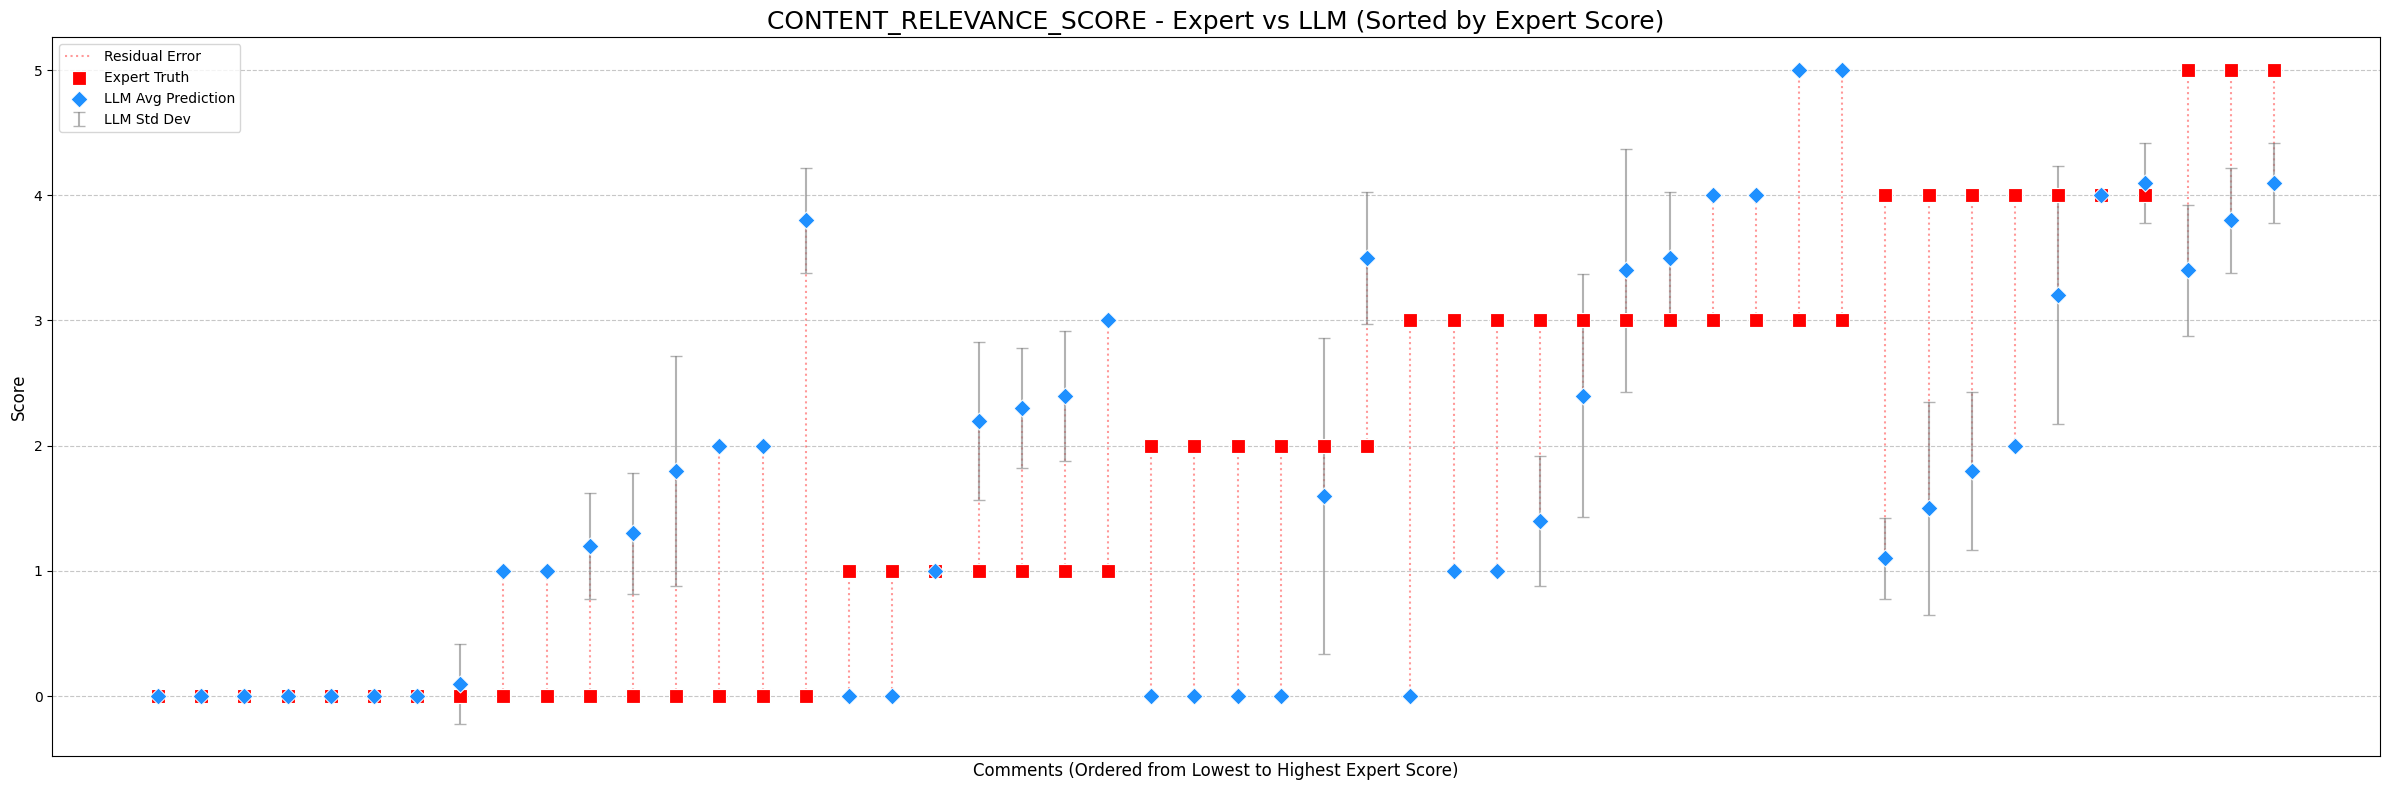

[[8 4 3 0 1 0]
 [2 1 3 1 0 0]
 [4 0 1 0 1 0]
 [1 3 1 1 3 2]
 [0 1 3 1 2 0]
 [0 0 0 1 2 0]]
[[16.  8.  6.  0.  2.  0.]
 [ 4.  2.  6.  2.  0.  0.]
 [ 8.  0.  2.  0.  2.  0.]
 [ 2.  6.  2.  2.  6.  4.]
 [ 0.  2.  6.  2.  4.  0.]
 [ 0.  0.  0.  2.  4.  0.]]


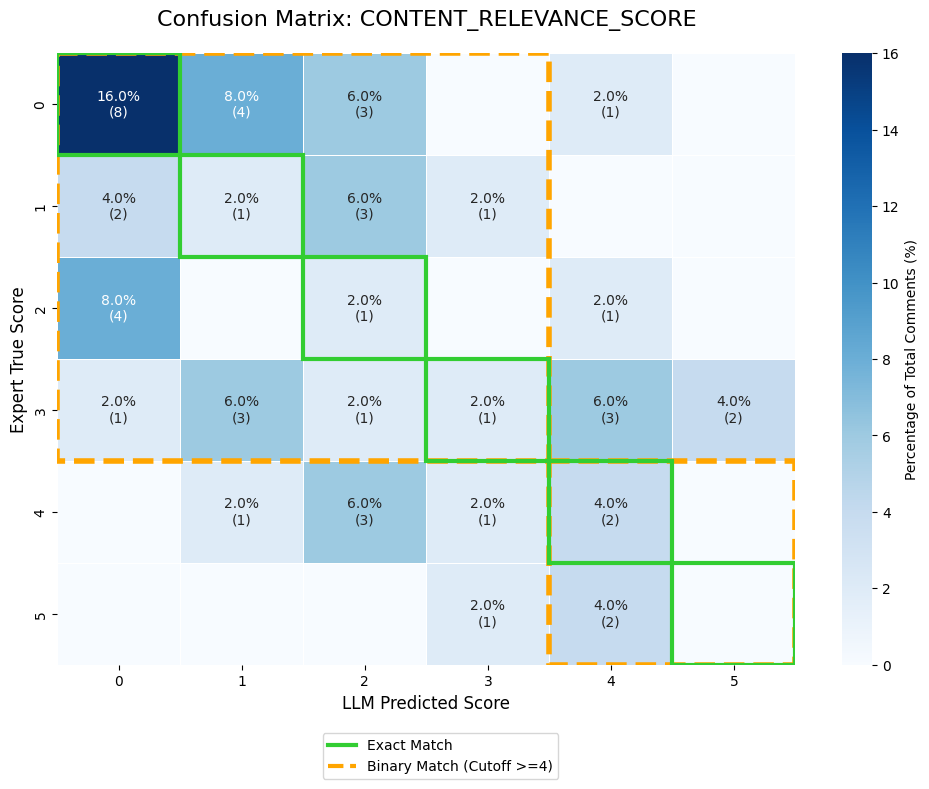

categorical
[[0 0 1 0 1 0]
 [0 5 0 0 1 1]
 [0 1 3 0 1 1]
 [0 0 0 3 2 0]
 [0 0 0 0 4 1]
 [0 0 0 0 1 4]]
[[ 0.          0.          3.33333333  0.          3.33333333  0.        ]
 [ 0.         16.66666667  0.          0.          3.33333333  3.33333333]
 [ 0.          3.33333333 10.          0.          3.33333333  3.33333333]
 [ 0.          0.          0.         10.          6.66666667  0.        ]
 [ 0.          0.          0.          0.         13.33333333  3.33333333]
 [ 0.          0.          0.          0.          3.33333333 13.33333333]]


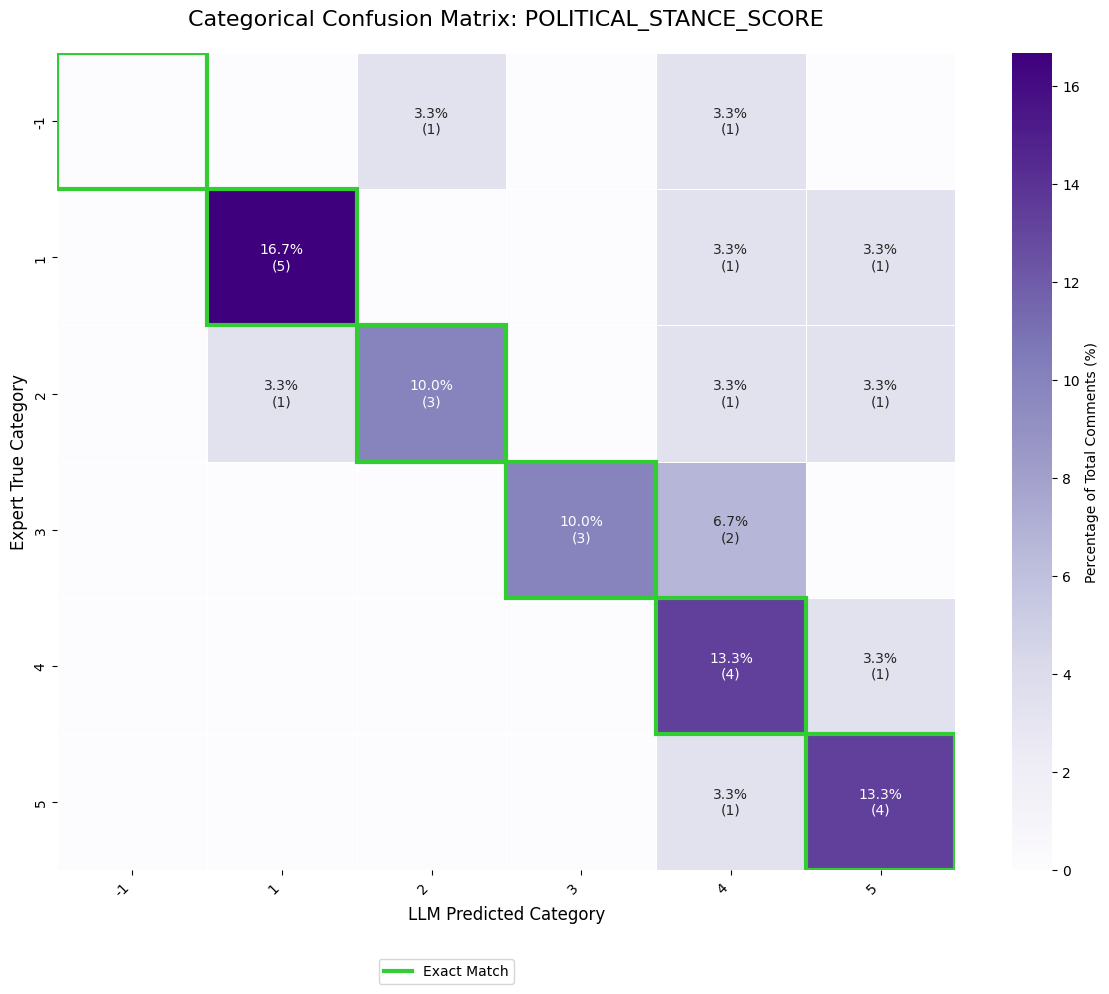

ordinal


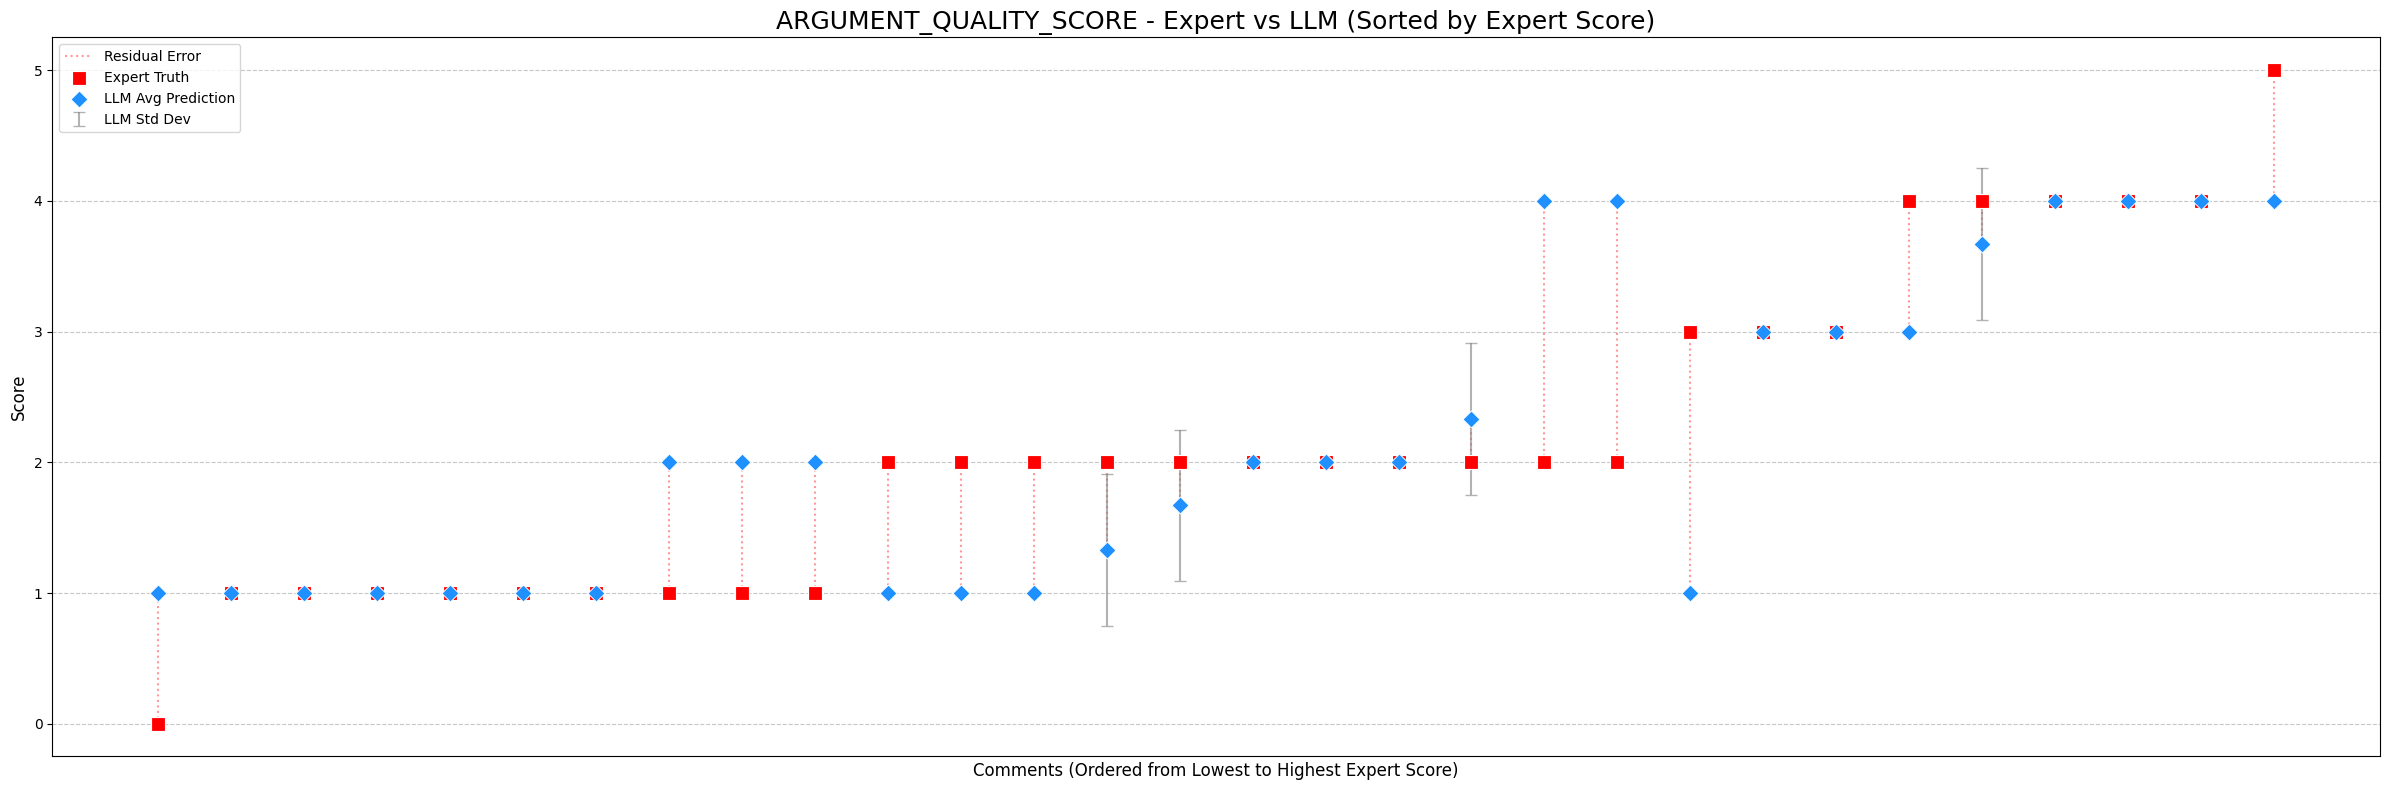

[[0 1 0 0 0 0]
 [0 6 3 0 0 0]
 [0 4 5 0 2 0]
 [0 1 0 2 0 0]
 [0 0 0 1 4 0]
 [0 0 0 0 1 0]]
[[ 0.          3.33333333  0.          0.          0.          0.        ]
 [ 0.         20.         10.          0.          0.          0.        ]
 [ 0.         13.33333333 16.66666667  0.          6.66666667  0.        ]
 [ 0.          3.33333333  0.          6.66666667  0.          0.        ]
 [ 0.          0.          0.          3.33333333 13.33333333  0.        ]
 [ 0.          0.          0.          0.          3.33333333  0.        ]]


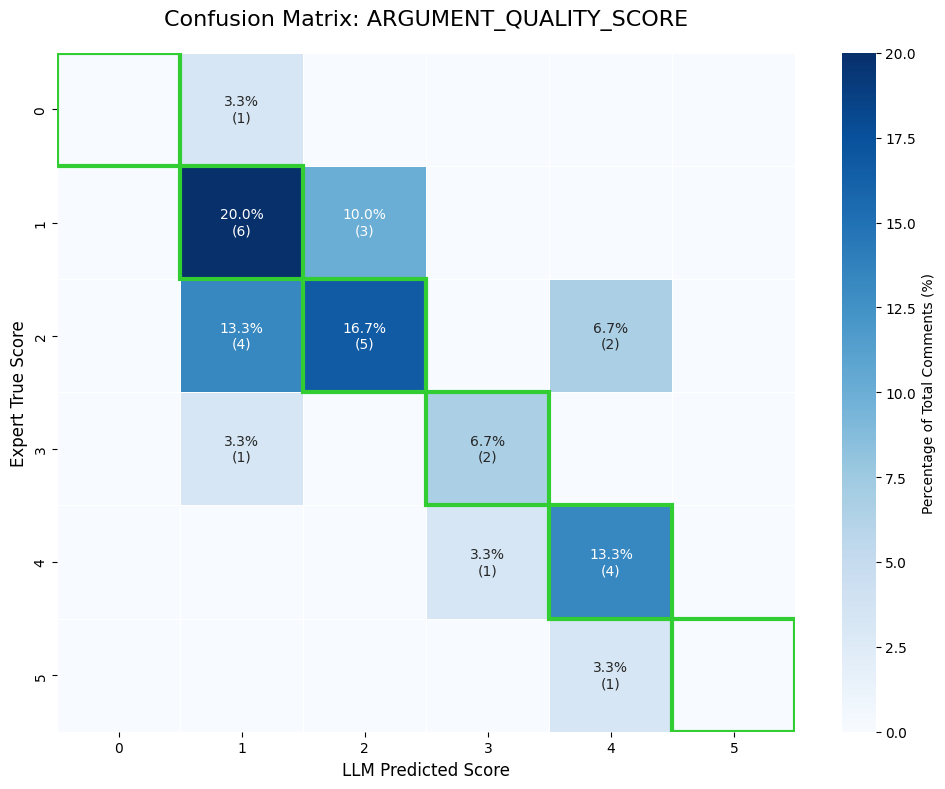

continuous


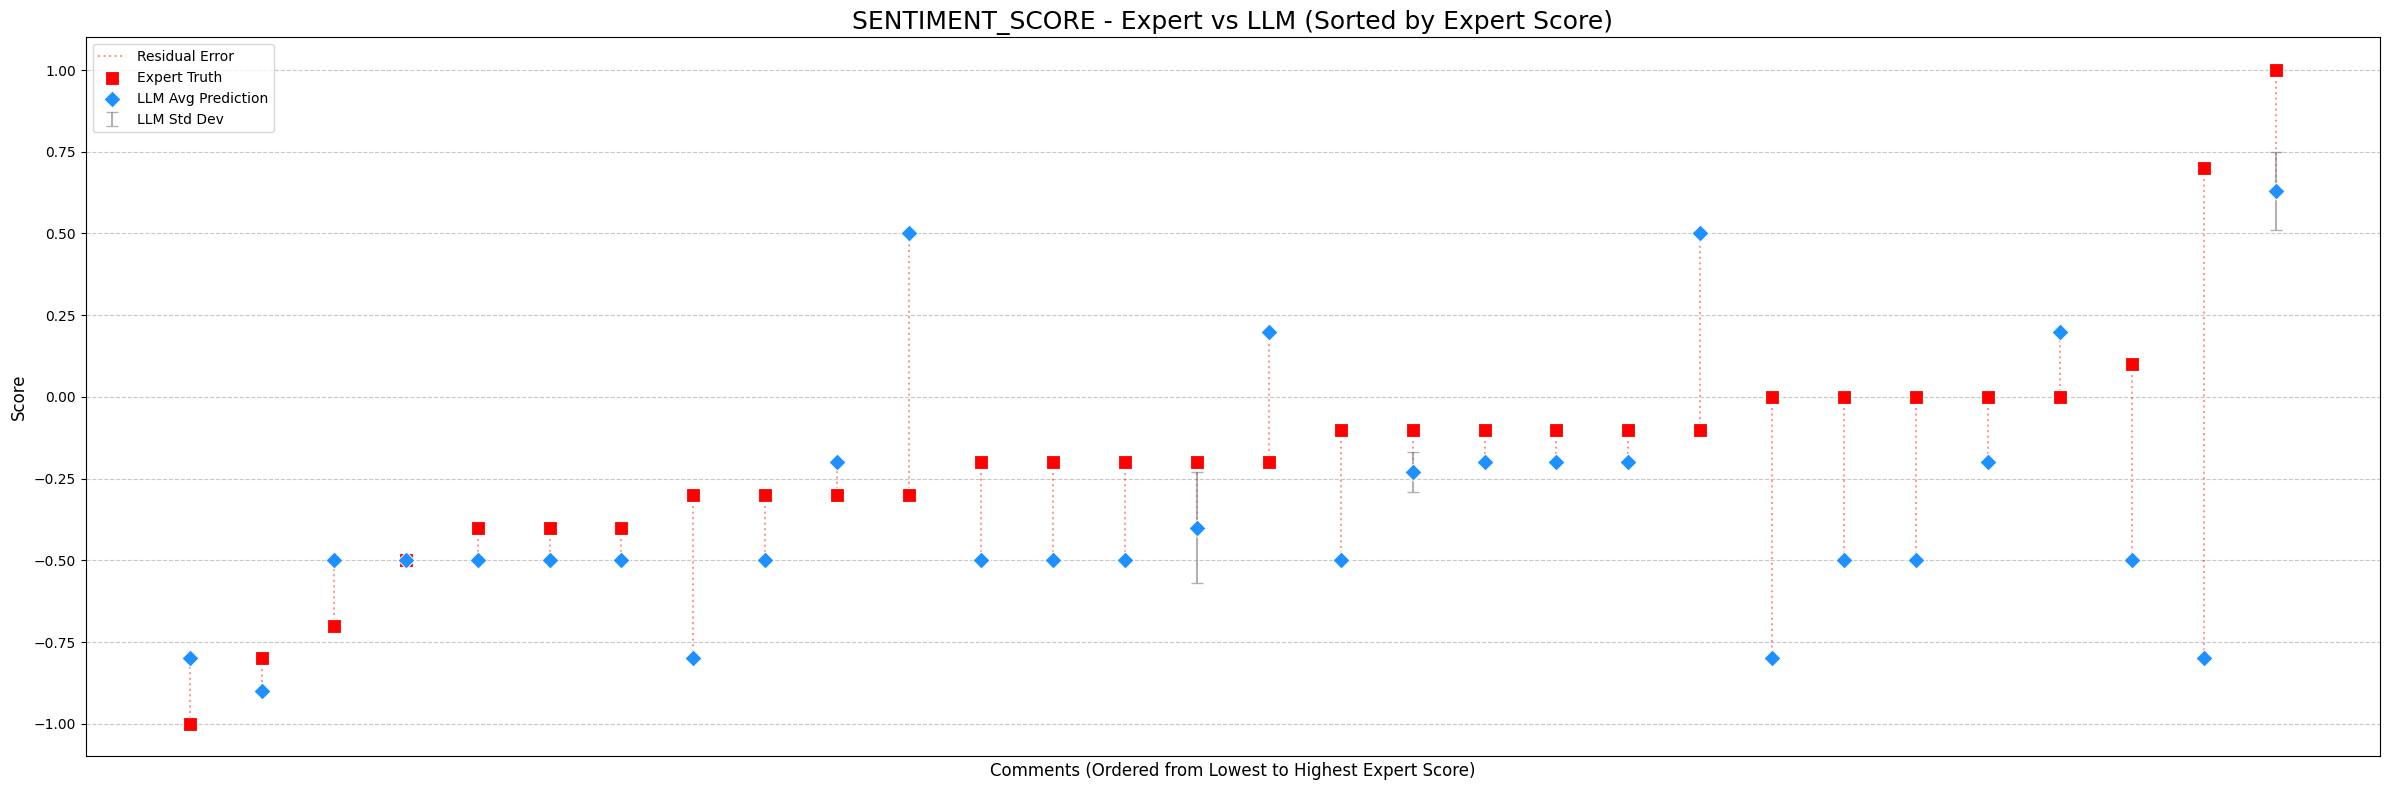

categorical
[[7 1 0 1 0]
 [1 8 2 1 0]
 [0 0 5 0 0]
 [0 0 0 2 0]
 [0 1 0 0 1]]
[[23.33333333  3.33333333  0.          3.33333333  0.        ]
 [ 3.33333333 26.66666667  6.66666667  3.33333333  0.        ]
 [ 0.          0.         16.66666667  0.          0.        ]
 [ 0.          0.          0.          6.66666667  0.        ]
 [ 0.          3.33333333  0.          0.          3.33333333]]


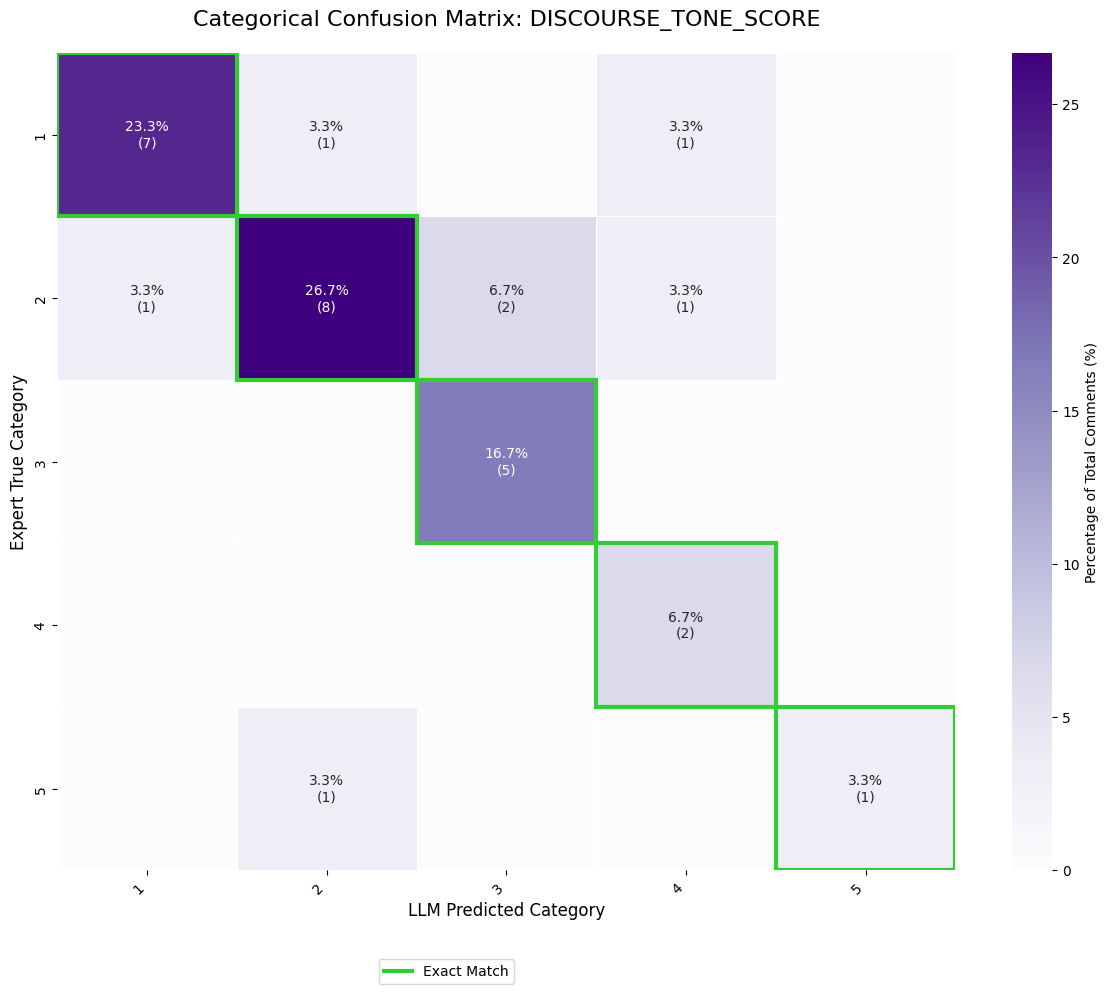

categorical
[[6 2 0 0 1 1 0 0]
 [1 2 0 0 0 0 0 0]
 [3 2 4 1 0 0 1 0]
 [0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [2 0 0 0 1 0 0 0]]
[[20.          6.66666667  0.          0.          3.33333333  3.33333333
   0.          0.        ]
 [ 3.33333333  6.66666667  0.          0.          0.          0.
   0.          0.        ]
 [10.          6.66666667 13.33333333  3.33333333  0.          0.
   3.33333333  0.        ]
 [ 0.          0.          0.          3.33333333  0.          0.
   0.          0.        ]
 [ 3.33333333  0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 3.33333333  0.          0.          0.          0.          0.
   0.          0.        ]
 [ 6.66666667  0.          0.          0.          3.33333333  0.
   0.          0.        ]]


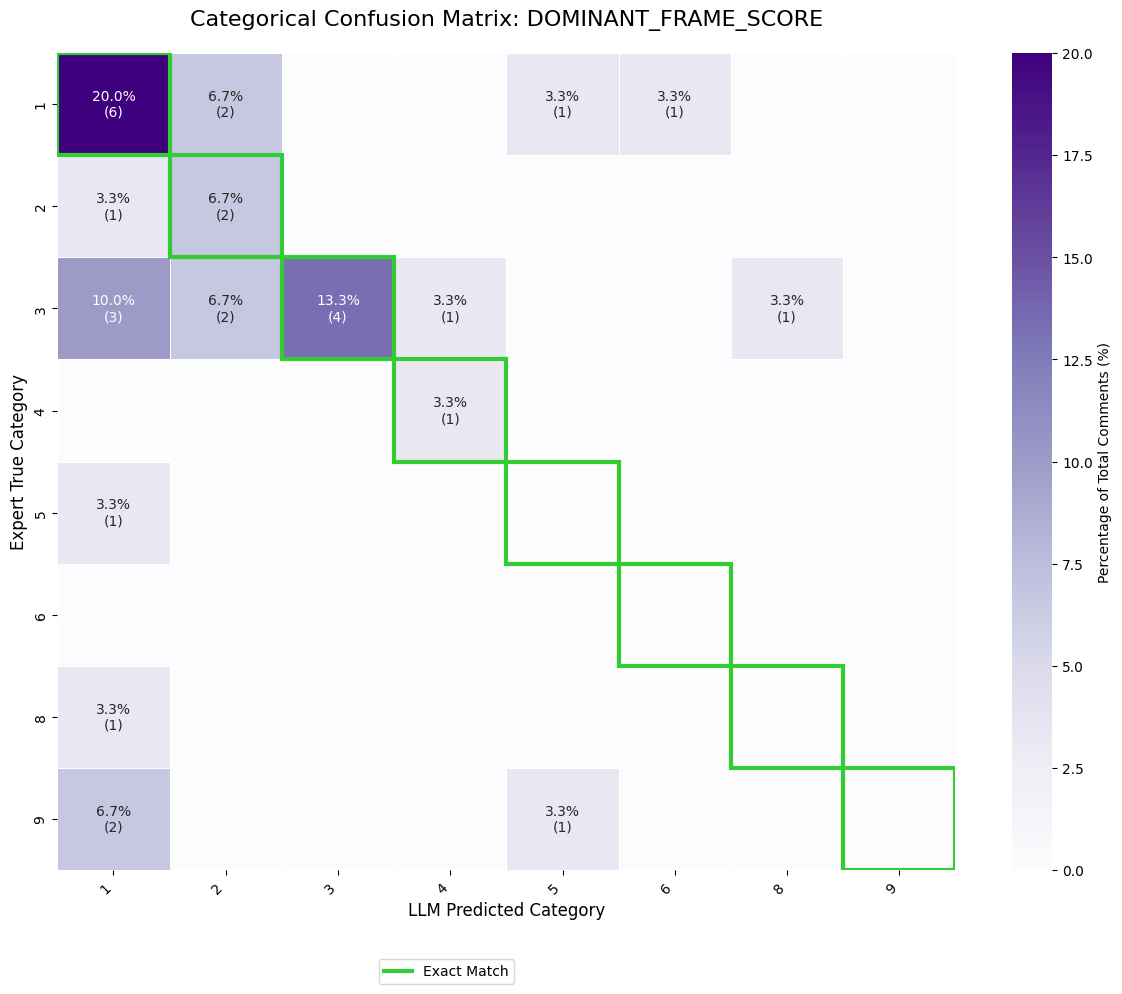

In [31]:
for feature_name in feature_names:

    try: 
        feature_type = FEATURE_CONFIG[feature_name]['type']
        print(feature_type)
        
        # Deduplicamos para tener 1 fila por comment_id
        df_feat_unique = df_plot[feature_name].unique(subset=["comment_id"], keep="first", maintain_order=True)

        # =====================================================================
        # 1. VISUALIZACIONES PARA VARIABLES ORDINALES Y CONTINUAS
        # =====================================================================
        if feature_type in ['ordinal', 'continuous']:
            
            # --- A. SCATTER PLOT ORDENADO (Staircase Plot) ---
            df_sorted = df_feat_unique.sort([feature_name, "predicted_values_mean"]).with_row_index(name="plot_index")
            plt.figure(figsize=(24, 8))

            plot_idx = df_sorted["plot_index"].to_numpy()
            y_mean = df_sorted["predicted_values_mean"].to_numpy()
            y_std = df_sorted["predicted_values_std"].to_numpy()
            y_true = df_sorted[feature_name].to_numpy()

            # Variabilidad y Error
            plt.errorbar(x=plot_idx, y=y_mean, yerr=y_std, fmt='none', ecolor='gray', elinewidth=1.5, capsize=4, alpha=0.6, zorder=5, label='LLM Std Dev')
            plt.vlines(x=plot_idx, ymin=y_true, ymax=y_mean, colors='red', linestyles='dotted', alpha=0.4, linewidth=1.5, label='Residual Error')

            df_sns = df_sorted.to_pandas()
            sns.scatterplot(data=df_sns, x="plot_index", y=feature_name, color="red", s=110, marker="s", label="Expert Truth", zorder=10)
            sns.scatterplot(data=df_sns, x="plot_index", y="predicted_values_mean", color="dodgerblue", s=75, marker="D", label="LLM Avg Prediction", zorder=11)

            plt.title(f"{feature_name.upper()} - Expert vs LLM (Sorted by Expert Score)", fontsize=18)
            plt.xlabel("Comments (Ordered from Lowest to Highest Expert Score)", fontsize=12)
            plt.ylabel("Score", fontsize=12)
            plt.xticks([]) 
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.legend(loc='upper left')
            plt.tight_layout()
            plt.show()

            # --- B. MATRIZ DE CONFUSIÓN CON % Y CUADRANTES BINARIOS ---
            if feature_type == 'ordinal':
                y_true_cm = df_feat_unique[feature_name].cast(pl.Int32).to_list()
                y_pred_cm = df_feat_unique["predicted_values_mean"].round(0).cast(pl.Int32).to_list()
                
                classes = sorted(list(set(y_true_cm) | set(y_pred_cm)))
                cm = confusion_matrix(y_true_cm, y_pred_cm, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                print(cm)
                print(cm_perc)
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(10, 8))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Blues', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # 1. Diagonal: Aciertos Puros
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                if feature_name == 'content_relevance_score':
                    # 2. Cuadrantes: Aciertos Binarios (Basados en el cutoff)
                    cutoff = FEATURE_CONFIG[feature_name].get('cutoff', 4) # Extraemos el cutoff, por defecto 4
                    
                    # Buscamos en qué índice de la matriz cae el cutoff
                    split_idx = next((i for i, c in enumerate(classes) if c >= cutoff), None)
                    
                    if split_idx is not None and split_idx > 0:
                        # Caja de Verdaderos Negativos (< cutoff)
                        ax.add_patch(patches.Rectangle(
                            (0, 0), split_idx, split_idx, 
                            fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                        ))
                        # Caja de Verdaderos Positivos (>= cutoff)
                        ax.add_patch(patches.Rectangle(
                            (split_idx, split_idx), len(classes) - split_idx, len(classes) - split_idx, 
                            fill=False, edgecolor='orange', lw=4, ls='--', zorder=9
                        ))

                    # Leyendas manuales
                    pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                    binary_hit_line = mlines.Line2D([], [], color='orange', lw=3, linestyle='--', label=f'Binary Match (Cutoff >={cutoff})')
                    ax.legend(handles=[pure_hit_line, binary_hit_line], loc='upper left', bbox_to_anchor=(0.35, -0.1))

                plt.title(f"Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Score", fontsize=12)
                plt.ylabel("Expert True Score", fontsize=12)
                
                plt.tight_layout()
                plt.show()

        # =====================================================================
        # 2. VISUALIZACIONES PARA VARIABLES CATEGÓRICAS
        # =====================================================================
        elif feature_type == 'categorical':
            
            pred_col = "predicted_values_mode" 
            if pred_col in df_feat_unique.columns:
                try:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.String).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.String).to_list()
                except AttributeError:
                    y_true_cat = df_feat_unique[feature_name].cast(pl.Utf8).to_list()
                    y_pred_cat = df_feat_unique[pred_col].cast(pl.Utf8).to_list()
                
                classes = sorted(list(set(y_true_cat) | set(y_pred_cat)))
                cm = confusion_matrix(y_true_cat, y_pred_cat, labels=classes)
                cm_perc = (cm / np.sum(cm)) * 100
                print(cm)
                print(cm_perc)
                
                # Anotaciones limpias (solo si > 0)
                annot_data = np.empty_like(cm, dtype=object)
                for i in range(cm.shape[0]):
                    for j in range(cm.shape[1]):
                        annot_data[i, j] = f"{cm_perc[i, j]:.1f}%\n({cm[i, j]})" if cm[i, j] > 0 else ""

                fig, ax = plt.subplots(figsize=(12, 10))
                sns.heatmap(cm_perc, annot=annot_data, fmt='', cmap='Purples', xticklabels=classes, yticklabels=classes,
                            linewidths=.5, cbar_kws={'label': 'Percentage of Total Comments (%)'}, ax=ax)
                
                # Resaltar la diagonal principal (Aciertos en clases categóricas)
                for i in range(len(classes)):
                    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='limegreen', lw=3, zorder=10))

                plt.title(f"Categorical Confusion Matrix: {feature_name.upper()}", fontsize=16, pad=20)
                plt.xlabel("LLM Predicted Category", fontsize=12)
                plt.ylabel("Expert True Category", fontsize=12)
                plt.xticks(rotation=45, ha='right')
                
                pure_hit_line = mlines.Line2D([], [], color='limegreen', lw=3, label='Exact Match')
                ax.legend(handles=[pure_hit_line], loc='upper left', bbox_to_anchor=(0.35, -0.1))
                
                plt.tight_layout()
                plt.show()
    except Exception as e:
        print(f"Exception: {e}")        

In [32]:
true_predicted_values_df['political_stance_score'].filter(pl.col('political_stance_score') == 2)

comment_id,political_stance_score,predicted_values,predicted_values_mode,predicted_values_consistency,predicted_values_variability
str,i64,list[str],str,f64,f64
"""mvwxu4r""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""mtwl83s""",2,"[""5"", ""5"", ""5""]","""5""",1.0,0.0
"""my7v96k""",2,"[""1"", ""1"", ""1""]","""1""",1.0,0.0
"""nd24kod""",2,"[""2"", ""2"", ""2""]","""2""",1.0,0.0
"""mz8ans8""",2,"[""4"", ""4"", ""4""]","""4""",1.0,0.0
"""n27i0kt""",2,"[""2"", ""2"", ""1""]","""2""",0.666667,0.333333
